Symulacja 1000 eksperymentów:
 [ 8 10 13  9 13 14 12 10 10 11 13 10 13 12 12  9 10 10 11 12 10  9 11 13
 12 11  7  7 12 11 12 16 12 13 11 10 10 11  9  9  6 10 11 10 11  8  8 10
  8  7  8 13  9 11 12 12 13  6 11  7  7 10 10 10 11  7 13 12  9 10  7  7
 11 13  9  9  8 10  9  5  7  9 12 12 11 11  9  7 14  8 10 11 14  9  8 12
 10  9  7 10 10 10  9 11 11 10 11 10  9 11 13 11 11 11 10 12  9  9 12  9
 13  8 11  9 12  9  8  9  8 13 13  4  8  6 11 12  8  8  9 13 15 11  8 10
 14  4 10 12  8 10  8  9  6  9 14 14  6  8 11  8  6  7 10 11  9 13  8 10
 10 10 11  5  9 11 11 12 10 12 12 11 14 10  8  9  6  9  9 12  9  8 15  9
  6  7 10 10 10  6 11 10  9 10 10 11 13 13  9 10  4  9  5 11 11  5 13 13
 13 11 12 11  6 12  7 10 10  9 12 11  9  9  9  8 11  9  9 12 11  9  9  8
 12  9  9  6  9 11  6  9 10  9  9 10  8 11  9  8 11  6  9 11 10  8  8 10
 12 13  8 11  8  8 10  9 13  8 12 10 10 11  9 11  7 14 11  7  8  8  8  8
  8  8  9 10 11  9  8 12 11 14  9  9 10  7 10 10 10 11 10 11 12 10 11 14
 14 15 11  9 14 10 1

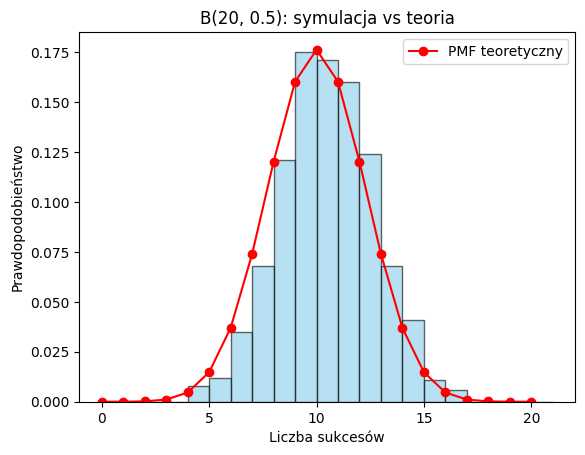

Średnia empiryczna: 9.998
Średnia teoretyczna: 10.0


In [11]:
# Symuluj 1000 eksperymentów rzutu 20 monetami (p=0.5). Porównaj histogram wyników z
# teoretycznym rozkładem dwumianowym B(20, 0.5).
# Dataset:
# Wygeneruj używając np.random.binomial()
# Wymagania:
# Symulacja 1000 eksperymentów
# Histogram wyników symulacji
# Teoretyczny PMF rozkładu B(20, 0.5) nałożony na histogram
# Porównanie średniej empirycznej z teoretyczną

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

n_trials = 20
p_success = 0.5

wynik = np.random.binomial(n_trials, p_success, size=1000)
print("Symulacja 1000 eksperymentów:\n", wynik)

# histogram (znormalizowany!)
plt.hist(wynik, bins=range(n_trials+2), density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Teoretyczny PMF rozkładu B(20, 0.5) nałożony na histogram
x = np.arange(0, n_trials + 1)
pmf_binom = binom.pmf(x, n=n_trials, p=p_success)

# nałożenie PMF
plt.plot(x, pmf_binom, 'o-', color='red', label='PMF teoretyczny')

# opisy
plt.xlabel('Liczba sukcesów')
plt.ylabel('Prawdopodobieństwo')
plt.title('B(20, 0.5): symulacja vs teoria')
plt.legend()

plt.show()

# Porównanie średniej empirycznej z teoretyczną
srednia_empiryczna = np.mean(wynik)
srednia_teoretyczna = n_trials * p_success

print("Średnia empiryczna:", srednia_empiryczna)
print("Średnia teoretyczna:", srednia_teoretyczna)

0        9.4
1        9.8
2        9.8
3        9.8
4        9.4
        ... 
1594    10.5
1595    11.2
1596    11.0
1597    10.2
1598    11.0
Name: alcohol, Length: 1599, dtype: float64

Przed usunięciem outlierów:
Mean: 10.422983114446529
Median: 10.2
Std: 1.0656675818473946

PO usunięciu outlierów:
Mean: 10.404431175361408
Median: 10.1
Std: 1.0354131818542127


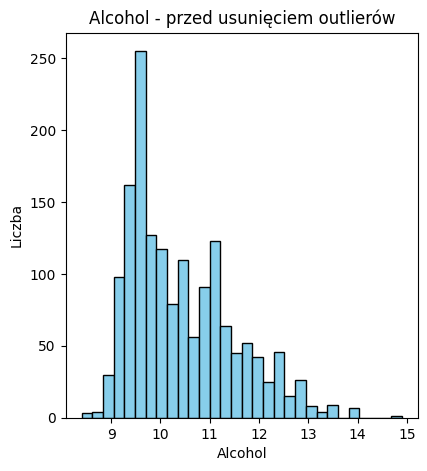

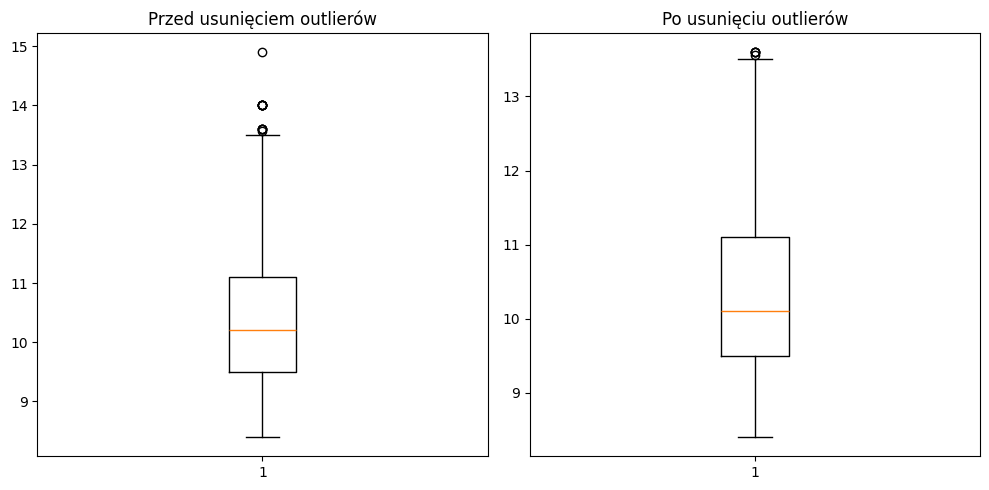

In [5]:
# Dla datasetu Wine Quality zidentyfikuj outliery w kolumnie alcohol metodą z-score
# (wartości > mean ± 3*std). Usuń outliery i porównaj statystyki przed/po.
# Dataset:
# Wine Quality
# Wymagania:
# Oblicz z-scores
# Zidentyfikuj outliery (|z| > 3)
# Boxplot przed i po usunięciu
# Porównanie statystyk (mean, median, std)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
# import seaborn as sns

# Wczytanie datasetu Wine Quality (red wine)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

# Kolumna
kolumna = wine["alcohol"]
print(kolumna)

# Oblicz z-scores
z_scores = (kolumna - kolumna.mean()) / kolumna.std() # np.abs(stats.zscore(col))

# Outliery
outliers = np.abs(z_scores) > 3 #np.abs(z) zamienia liczby na ich „odległość od zera”, np -2 -> 2

# usunięcie outlierów
clean = wine[~outliers] #~ tylko dobre dane

plt.figure(figsize=(10,5))

# PRZED usunięciem
plt.subplot(1,2,1)
plt.hist(kolumna, bins=30, color='skyblue', edgecolor='black')
plt.title("Alcohol - przed usunięciem outlierów")
plt.xlabel("Alcohol")
plt.ylabel("Liczba")

# Statystyki PRZED 

print("\nPrzed usunięciem outlierów:")
print("Mean:", kolumna.mean())
print("Median:", kolumna.median())
print("Std:", kolumna.std())

# Statystyki PO
kolumna_clean = clean["alcohol"]

print("\nPO usunięciu outlierów:")
print("Mean:", kolumna_clean.mean())
print("Median:", kolumna_clean.median())
print("Std:", kolumna_clean.std())

# BOXPLOT
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(kolumna)
plt.title("Przed usunięciem outlierów")

plt.subplot(1,2,2)
plt.boxplot(kolumna_clean)
plt.title("Po usunięciu outlierów")

plt.tight_layout()
plt.show()